## Multiple Linear Regression

Multiple Independent features

One Dependent feature

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [62]:
df = pd.read_csv("economics_index.csv")
df.head()

,Year,Month,Interest_Rate,Unemployment_Rate,Index_Price
0,2022,1,2.7,5.4,1450
1,2022,2,2.6,5.7,1465
2,2022,3,2.7,5.4,1480
3,2022,4,2.1,5.1,1495
4,2022,5,2.8,5.4,1510


In [63]:
#drop unneccesory coloumn 
df.drop(columns=["Month", "Year"], inplace=True)

In [64]:
df.head()

,Interest_Rate,Unemployment_Rate,Index_Price
0,2.7,5.4,1450
1,2.6,5.7,1465
2,2.7,5.4,1480
3,2.1,5.1,1495
4,2.8,5.4,1510


In [65]:
#Cheak null values
df.index.isnull().sum()

np.int64(0)

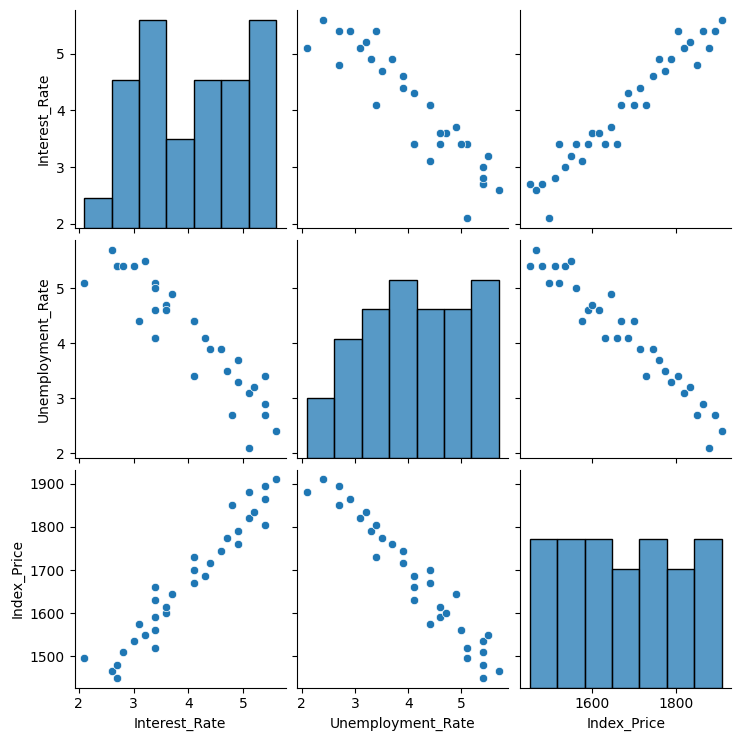

In [66]:
#Visualization 
import seaborn as sns 
sns.pairplot(df)

In [68]:
#Correlation 
df.corr()
#As Interest_Rate increase Index_price also increase 
#If Unemployement_Rate increases Index_price decreases 

,Interest_Rate,Unemployment_Rate,Index_Price
Interest_Rate,1.000000,-0.905669,0.966636
Unemployment_Rate,-0.905669,1.000000,-0.965501
Index_Price,0.966636,-0.965501,1.000000


Text(0, 0.5, 'Unemployement_Rate')

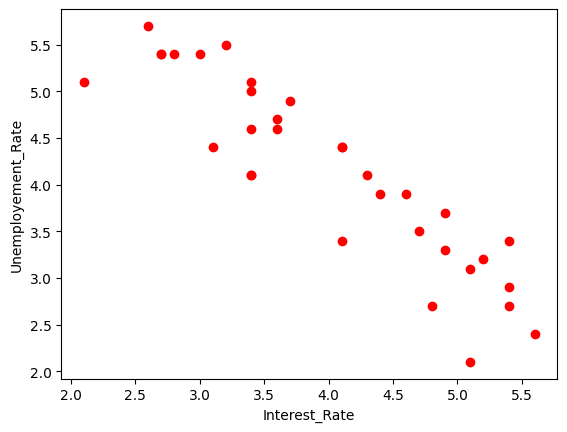

In [72]:
# Visualization of datapoints more closely
plt.scatter(df['Interest_Rate'],df['Unemployment_Rate'],color='r')
plt.xlabel("Interest_Rate")
plt.ylabel("Unemployement_Rate")

In [74]:
## Independent Feature
X = df.iloc[:,:-1] # Means take all the coloumn excpet last one which is dependent feature 

In [ ]:
# Dependent Feature
Y = df.iloc[:,-1] # Take only last Coloumn 

In [76]:
X.head()

,Interest_Rate,Unemployment_Rate
0,2.7,5.4
1,2.6,5.7
2,2.7,5.4
3,2.1,5.1
4,2.8,5.4


In [77]:
Y.head()

0    1450
1    1465
2    1480
3    1495
4    1510
Name: Index_Price, dtype: int64

In [80]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.25,random_state=42)

In [82]:
X_train.count()

Interest_Rate        24
Unemployment_Rate    24
dtype: int64

In [83]:
X_test.count()

Interest_Rate        9
Unemployment_Rate    9
dtype: int64

<Axes: xlabel='Interest_Rate', ylabel='Index_Price'>

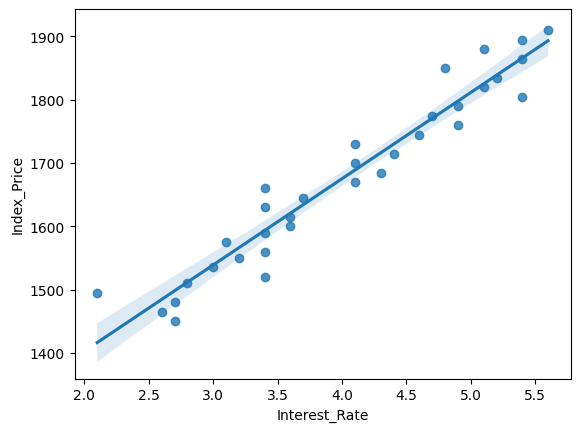

In [ ]:
## Regression Line 
import seaborn as sns 
sns.regplot(x=df['Interest_Rate'],y=df['Index_Price'])

<Axes: xlabel='Interest_Rate', ylabel='Unemployment_Rate'>

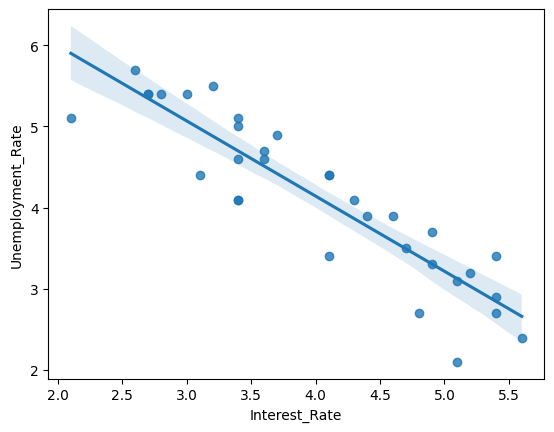

In [90]:
sns.regplot(x=df['Interest_Rate'],y=df['Unemployment_Rate'])

In [96]:
#Standardlization or Standard Scaling 
from sklearn.preprocessing import StandardScaler

In [97]:
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [ ]:
X_train

In [101]:
X_test

array([[ 1.63888641, -1.90349354],
       [-0.97172911,  0.1820733 ],
       [ 1.24729408, -1.3076173 ],
       [ 0.20304787,  0.1820733 ],
       [-0.97172911,  1.52279484],
       [-1.36332144,  0.62898048],
       [ 0.33357865, -0.11586482],
       [ 0.5946402 , -0.11586482],
       [-0.71066756,  0.9269186 ]])

In [102]:
from sklearn.linear_model import LinearRegression
regression= LinearRegression()

In [103]:
regression.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 75.55,-71.6 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1668
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[6.77,1.47]"


# Cross Validation 

suppose we have 1000 records. after train_test_split we gave 100 for test 900 for train then those 900 train data will be splited in Train and Validation 

Suppose the cross validation is 5 we will divide 900 by 5 and those 180 records will be there for test again and also we will first chose first 180 records then in second we will chose next 180 for test and rest for train and so on.

In [113]:
# Cross validation 
from sklearn.model_selection import cross_val_score 
validation_score = cross_val_score(regression,X_train,Y_train,scoring='neg_mean_squared_error',cv=3)

In [114]:
np.mean(validation_score)

np.float64(-686.0085001854983)

In [116]:
## Prediction
y_pred = regression.predict(X_test)
y_pred


array([1928.44067396, 1581.88191593, 1856.19147704, 1670.63761271,
       1485.88799546, 1520.29871018, 1701.83133913, 1721.5548273 ,
       1548.27544829])

In [120]:
## Performance Metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2488.543421287596
43.80714466780109
49.88530265807351


In [126]:
## R2 value 
from sklearn.metrics import r2_score
score = r2_score(Y_test,y_pred)
print(score)

## Adjusted R2 value 
print(1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1))

0.7734254851634965
0.697900646884662


## Assumptions 


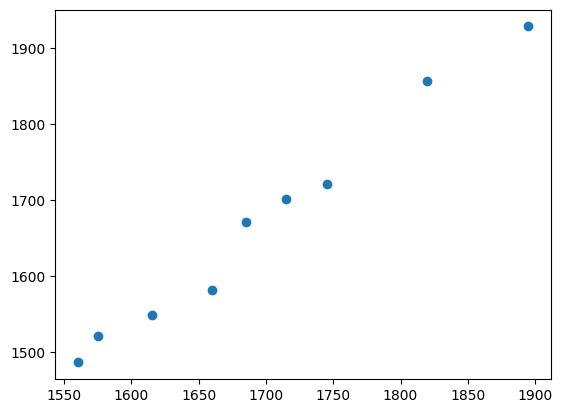

In [127]:
plt.scatter(Y_test,y_pred)

In [128]:
residuals = Y_test - y_pred
print(residuals)

31   -33.440674
15    78.118084
26   -36.191477
17    14.362387
8     74.112005
9     54.701290
19    13.168661
21    23.445173
12    66.724552
Name: Index_Price, dtype: float64


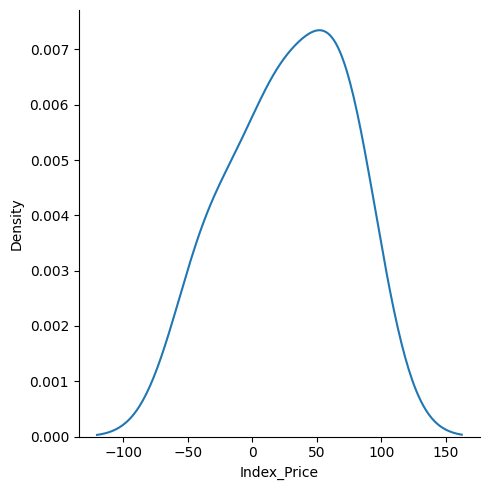

In [129]:
sns.displot(residuals,kind='kde')

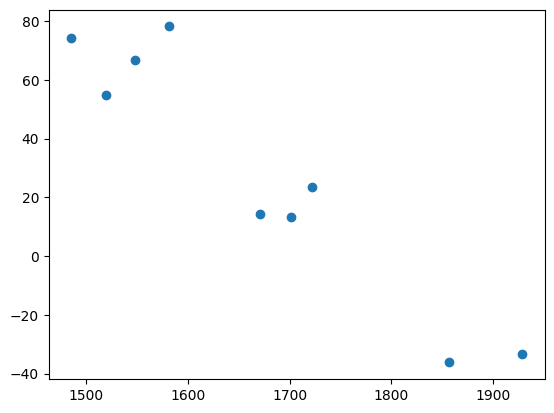

In [ ]:
## Scatter plot with respect to prediction and residuals 
plt.scatter(y_pred,residuals) # Datapoints are  Uniformly distributed 

### OLS Linear Regression

In [134]:
import statsmodels.api as sm
model = sm.OLS(Y_train,X_train).fit()

In [137]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            Index_Price   R-squared (uncentered):                   0.007
Model:                            OLS   Adj. R-squared (uncentered):             -0.083
Method:                 Least Squares   F-statistic:                            0.08171
Date:                Tue, 23 Jun 2026   Prob (F-statistic):                       0.922
Time:                        22:29:50   Log-Likelihood:                         -212.13
No. Observations:                  24   AIC:                                      428.3
Df Residuals:                      22   BIC:                                      430.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------